# Analysis of Omni-iEEG dataset, detection of HFO events

HFOs:
- They are spontaneous iEEG events in the 80–500 Hz frequency range
- characterized by at least four consecutive oscillations that clearly stand out from the background activity
- 30 to 1000 ms in duration


HFOs are typically divided into two bands:
- Ripples (80–250 Hz)
- Fast ripples (250–500 Hz)

Nyquist frequency: need a sampling frequency the double of the highest frequency of interest.

In [1]:
import os
import h5py
from torch_brain.data import Data
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from scipy.signal import spectrogram

In [2]:
# BIDS_ROOT = ("/capstor/scratch/cscs/davalos/data/processed/omni_ieeg")
# H5_FILENAME = "sub-openieegDetroit078_ses-01_task-sleep.h5"
BIDS_ROOT = "/Users/avalos/Documents/Programming/neurosoft_epilepsy/data/processed/omni_ieeg"
H5_FILENAME = "sub-openieegDetroit006_ses-01_task-sleep.h5"

### 1. Load .h5 file

In [3]:
with h5py.File(os.path.join(BIDS_ROOT, H5_FILENAME), "r") as f:
    data = Data.from_hdf5(f, lazy=False)

    print("Fields in data:")
    for key in data.keys():
        print("   - ", key)

Fields in data:
   -  annotations
   -  brainset
   -  channels
   -  device
   -  ieeg
   -  session
   -  subject
   -  dataset_name
   -  outcome
   -  split
   -  task_name


In [4]:
print(data.annotations)

Interval(
  start=[332],
  end=[332],
  artifact=[332],
  channel=[332],
  description=[332],
  detector=[332],
  method=[332],
  spike=[332]
)


In [101]:
for i in np.arange(1,10):
    print(data.annotations.channel[i])
    print(data.annotations.start[i])
    print(data.annotations.end[i])
    print(data.annotations.artifact[i])

b'A2-AV'
101.931
101.962
1
b'A3-AV'
188.845
188.898
0
b'A3-AV'
188.909
188.926
0
b'A3-AV'
188.94
189.15
0
b'A3-AV'
189.166
189.214
0
b'A3-AV'
189.225
189.247
0
b'A3-AV'
189.258
189.367
0
b'A3-AV'
189.381
189.4
0
b'A3-AV'
189.412
189.431
0


array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
data.ieeg

RegularTimeSeries(
  signal=[304000, 100]
)

### 2. Channels info

In [6]:
print("Channel names: ", data.channels.id[1:5])
print("Channel types: ", data.channels.type[1:5])

Channel names:  ['A2-AV' 'A3-AV' 'A4-AV' 'A5-AV']
Channel types:  ['eeg' 'eeg' 'eeg' 'eeg']


In [7]:
ch_names = data.channels.id
ch_types = data.channels.type
start_time = 0
signal = data.ieeg.signal  # ecog
timestamps = data.ieeg.timestamps  # ecog
timestamps
len(ch_names)

100

In [15]:
type(channel_idx)

NameError: name 'channel_idx' is not defined

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_21928/3868894973.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


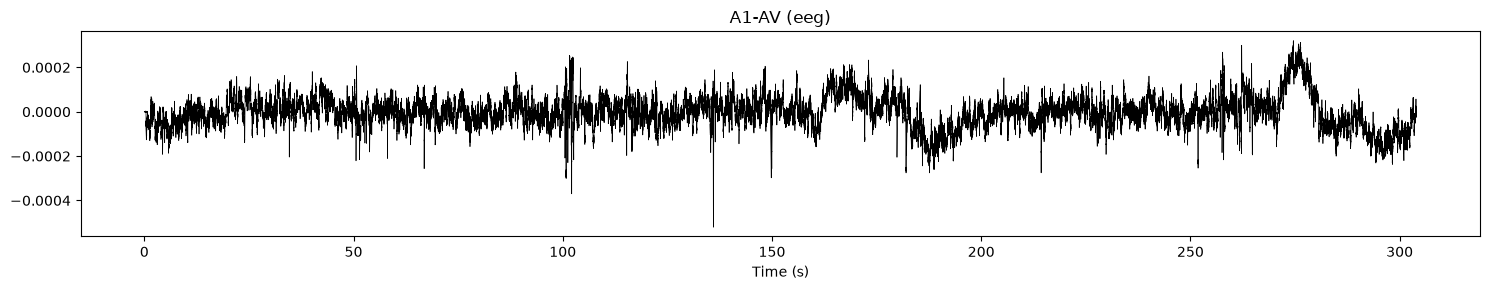

In [16]:
def plot_channel(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        timestamps[keep],
        signal[keep, channel_idx],
        color="black",
        linewidth=0.5,
    )
    ax.set_xlabel("Time (s)")
    ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]})")
    fig.tight_layout()
    return fig


fig = plot_channel(
    signal, timestamps, ch_names, ch_types, channel_idx=0, start_time=start_time
)
fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_21928/1587091524.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


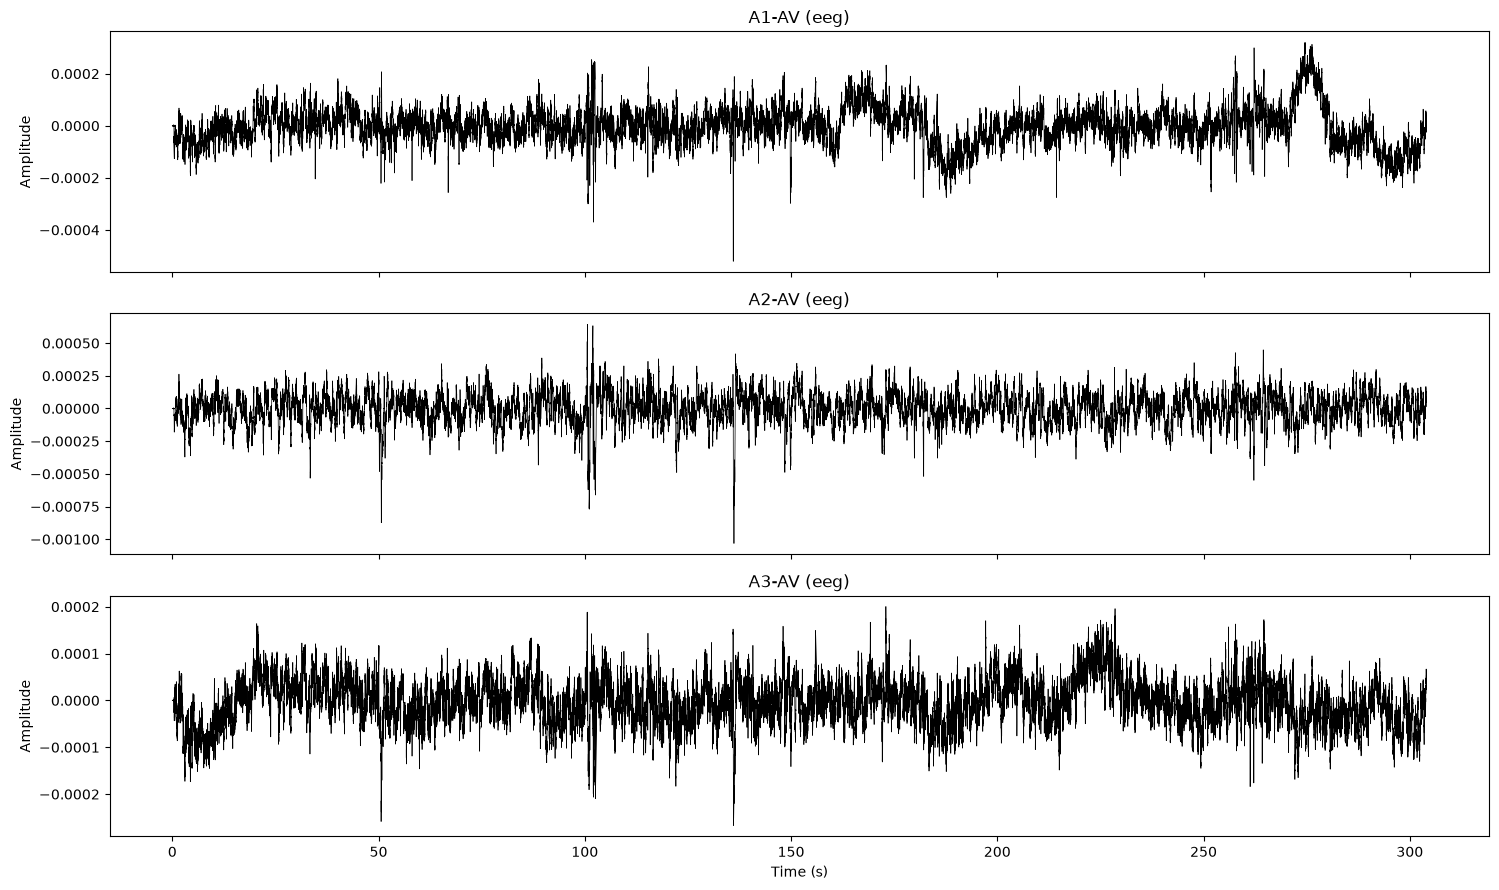

In [17]:
def plot_channels(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_indices: list[int] = [0, 1, 2],
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):

    n = len(channel_indices)

    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)

    fig, axes = plt.subplots(
        n, 1, figsize=(figsize[0], figsize[1] * n), sharex=True
    )

    if n == 1:
        axes = [axes]  # make it iterable when there's only one channel

    for ax, ch_idx in zip(axes, channel_indices):
        ax.plot(
            timestamps[keep], signal[keep, ch_idx], color="black", linewidth=0.5
        )
        ax.set_title(f"{ch_names[ch_idx]} ({ch_types[ch_idx]})")
        ax.set_ylabel("Amplitude")

    axes[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    return fig


fig = plot_channels(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_indices=np.arange(len(ch_names[0:3])),
    start_time=0,
    end_time=None,
    figsize=(15, 3),
)
fig.show()

### 3. iEEG data visualization

In [18]:
def plot_channel_with_hfo_events(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    annotations,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    figsize=(15, 3),
):
    """Plot one channel's raw signal with its doctor-annotated HFO events shaded.

    `annotations` is `data.annotations` after merging in HFO events (see
    `foundry.data.pipelines.omni_ieeg._build_annotations`) -- each event has a
    `channel`, `start`/`end` (seconds) and an `artifact` flag (1 = doctor
    marked it as an artifact, not a true HFO).
    """
    fig = plot_channel(
        signal,
        timestamps,
        ch_names,
        ch_types,
        channel_idx,
        start_time,
        end_time,
        figsize,
    )
    ax = fig.axes[0]

    ch_name = ch_names[channel_idx]
    on_channel = annotations.channel.astype(str) == ch_name

    legend_handles = {}
    for ev_start, ev_end, artifact in zip(
        annotations.start[on_channel],
        annotations.end[on_channel],
        annotations.artifact[on_channel],
    ):
        if (
            ev_start > (end_time if end_time is not None else timestamps[-1])
            or ev_end < start_time
        ):
            continue
        label = "HFO (artifact)" if artifact == 1 else "HFO"
        color = "red" if artifact == 1 else "orange"
        ax.axvspan(ev_start, ev_end, color=color, alpha=0.3, lw=0)
        legend_handles[label] = Patch(facecolor=color, alpha=0.3, label=label)

    if legend_handles:
        ax.legend(handles=list(legend_handles.values()), loc="upper right")
    return fig

In [19]:
ch_names

array(['A1-AV', 'A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV',
       'A8-AV', 'A9-AV', 'A10-AV', 'A11-AV', 'A12-AV', 'A13-AV', 'A14-AV',
       'A15-AV', 'A16-AV', 'A17-AV', 'A18-AV', 'A19-AV', 'A20-AV',
       'A21-AV', 'A22-AV', 'A23-AV', 'A24-AV', 'A25-AV', 'A26-AV',
       'A27-AV', 'A28-AV', 'A29-AV', 'A30-AV', 'A31-AV', 'A32-AV',
       'A33-AV', 'A34-AV', 'A35-AV', 'A36-AV', 'A37-AV', 'A38-AV',
       'A39-AV', 'A40-AV', 'A41-AV', 'A42-AV', 'A43-AV', 'A44-AV',
       'A45-AV', 'A46-AV', 'A47-AV', 'A48-AV', 'A49-AV', 'A50-AV',
       'A51-AV', 'A52-AV', 'A53-AV', 'A54-AV', 'A55-AV', 'A56-AV',
       'A57-AV', 'A58-AV', 'A59-AV', 'A60-AV', 'A61-AV', 'A62-AV',
       'A63-AV', 'A64-AV', 'B1-AV', 'B2-AV', 'B3-AV', 'B4-AV', 'B5-AV',
       'B6-AV', 'B7-AV', 'B8-AV', 'B9-AV', 'B10-AV', 'B11-AV', 'B12-AV',
       'B13-AV', 'B14-AV', 'B15-AV', 'B16-AV', 'B17-AV', 'B18-AV',
       'B19-AV', 'B20-AV', 'B21-AV', 'B22-AV', 'B23-AV', 'B24-AV',
       'B25-AV', 'B26-AV', 'B27-AV', 'B2

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_21928/1837334236.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


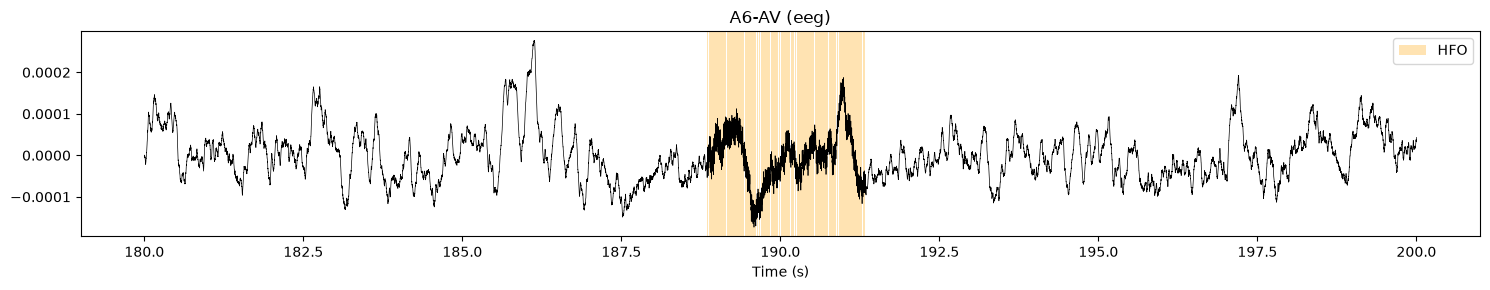

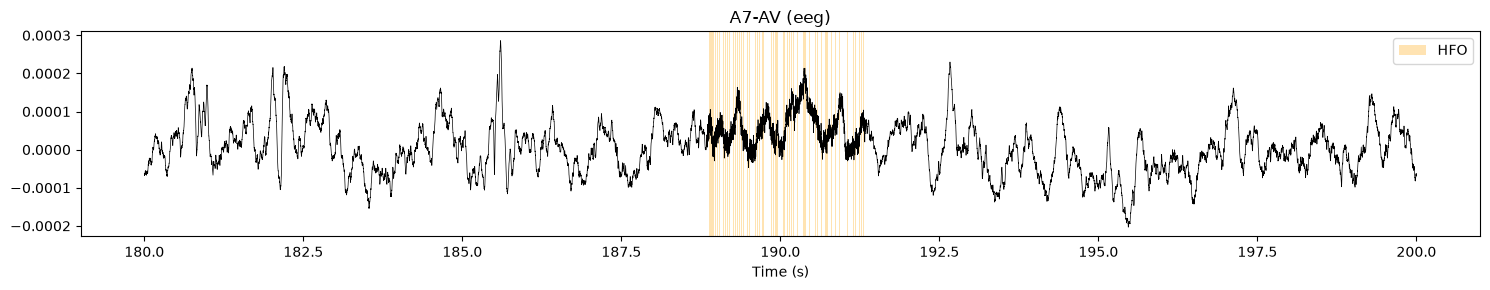

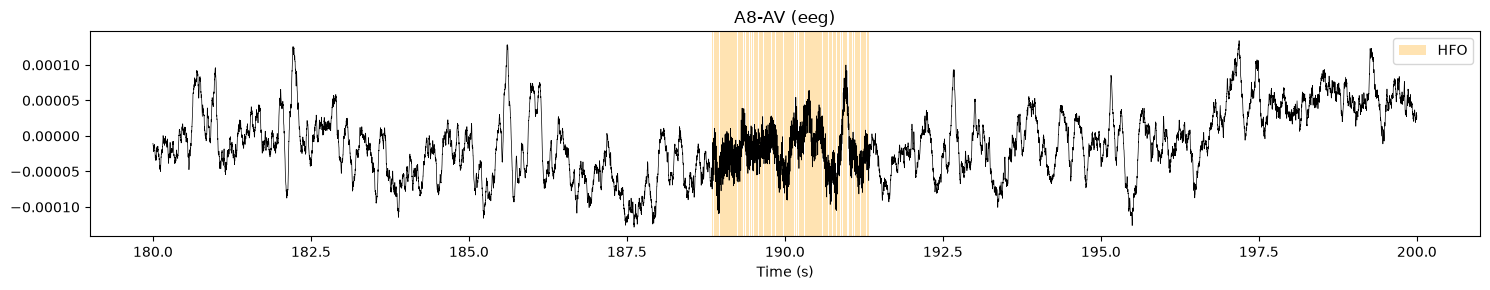

In [20]:
for ch_nbr in np.arange(5, 8):
    fig = plot_channel_with_hfo_events(
        signal,
        timestamps,
        ch_names,
        ch_types,
        data.annotations,
        channel_idx=ch_nbr,
        start_time=180,
        end_time=200,
    )
    fig.show()

In [22]:
def plot_channel_spectrogram(
    signal: np.ndarray,
    timestamps: np.ndarray,
    ch_names: np.ndarray,
    ch_types: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
    figsize=(15, 3),
):
    """Plot a spectrogram of one channel using a sliding window.

    `window_ms` is the length of each FFT segment; `step_ms` is how far the
    window slides between segments (so overlap = window_ms - step_ms).
    """
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(
        trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap
    )

    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
    )
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(
        f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram"
    )
    fig.tight_layout()
    return fig

In [26]:
def get_spectral_data(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(
        trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap
    )
    return t, freqs, times, sxx

In [25]:
def plot_spectrogram(t, freqs, times, sxx, channel_idx, figsize):
    # TODO add type hints
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
    )
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(
        f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram"
    )
    fig.tight_layout()
    return fig

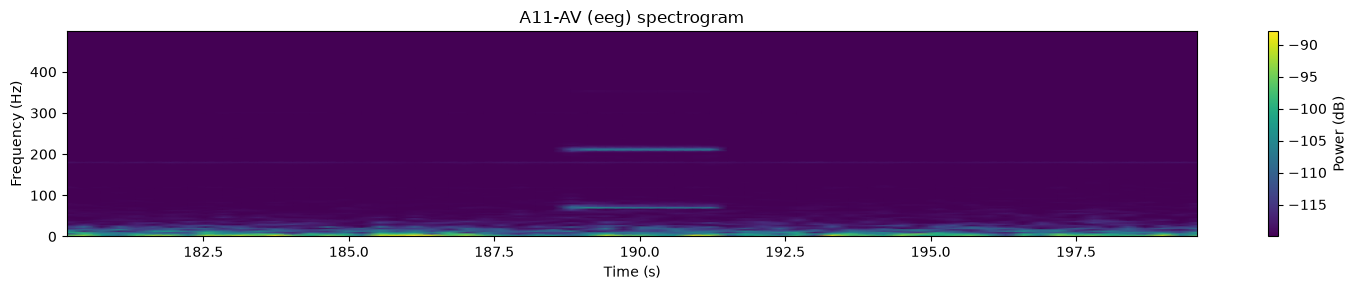

In [38]:
t, freqs, times, sxx = get_spectral_data(
    signal,
    timestamps,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=300,
    step_ms=300,
)

fig = plot_spectrogram(t, freqs, times, sxx, 10, figsize=(15, 3))

In [49]:
print(freqs.shape)
print(times.shape)
print(sxx.shape)

(150,)
(66,)
(150, 66)


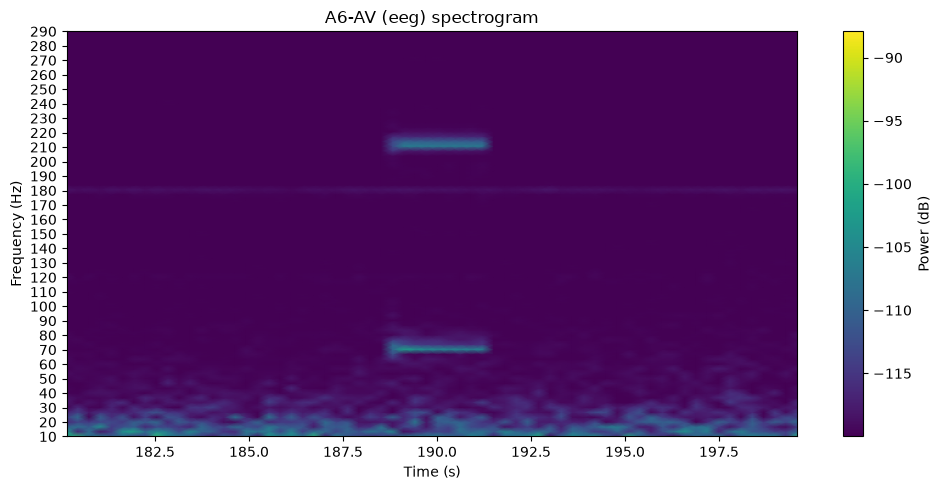

In [79]:
channel_idx = 5
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
)
fig.colorbar(mesh, ax=ax, label="Power (dB)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram")
ax.set_yticks(np.arange(0, freqs[-1] + 1, 10))  # tick every 10 Hz
ax.set_ylim(10, 290)
fig.tight_layout()

In [64]:
def plot_channel_spectra(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_names: list = None,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
    freq_range: tuple = (10, 500),
    db_scale: bool = True,
    highlight_hfo_bands: bool = True,
    ax=None,
):
    """
    Overlay averaged power spectra for all channels, for HFO screening.

    Parameters
    ----------
    signal : np.ndarray, shape (n_samples, n_channels)
    timestamps : np.ndarray, shape (n_samples,)
    channel_names : list of str, optional (defaults to "Ch0", "Ch1", ...)
    freq_range : tuple, x-axis limits in Hz (default 10-500 to cover ripples + fast ripples)
    db_scale : if True, plot 10*log10(power)
    highlight_hfo_bands : shades ripple (80-250 Hz) and fast ripple (250-500 Hz) bands
    ax : optional matplotlib Axes to plot into
    """
    n_channels = signal.shape[1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    for ch in range(n_channels):
        t, freqs, times, sxx = get_spectral_data(
            signal,
            timestamps,
            channel_idx=ch,
            start_time=start_time,
            end_time=end_time,
            window_ms=window_ms,
            step_ms=step_ms,
        )
        power = sxx.mean(axis=1)
        y = 10 * np.log10(power + 1e-20) if db_scale else power
        ax.plot(freqs, y, label=channel_names[ch], linewidth=1)

    if highlight_hfo_bands:
        ax.axvspan(
            80, 250, color="orange", alpha=0.1, label="Ripple (80-250 Hz)"
        )
        ax.axvspan(
            250, 500, color="red", alpha=0.1, label="Fast ripple (250-500 Hz)"
        )

    ax.set_xlim(freq_range)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)" if db_scale else "Power")
    ax.set_title("Power Spectrum by Channel")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

    return ax

In [69]:
ch_names[1:10]

array(['A2-AV', 'A3-AV', 'A4-AV', 'A5-AV', 'A6-AV', 'A7-AV', 'A8-AV',
       'A9-AV', 'A10-AV'], dtype='<U6')

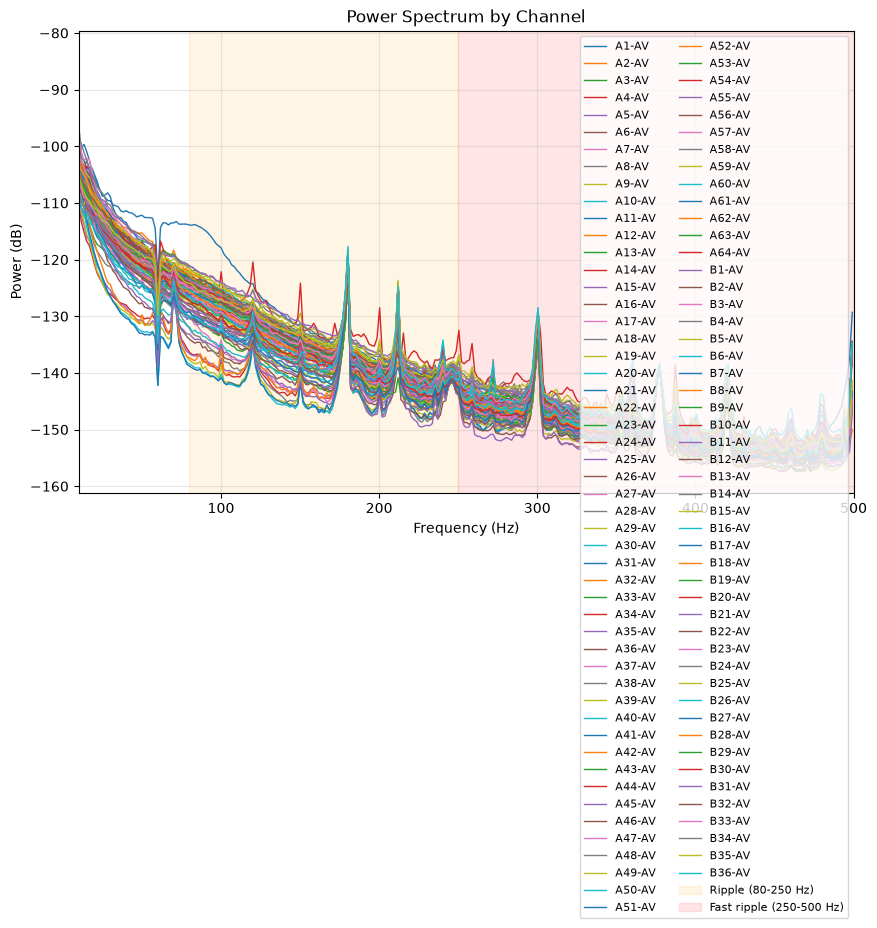

In [85]:
plot_channel_spectra(signal, timestamps, channel_names=ch_names[:])
plt.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_21928/1273006006.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_21928/1273006006.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


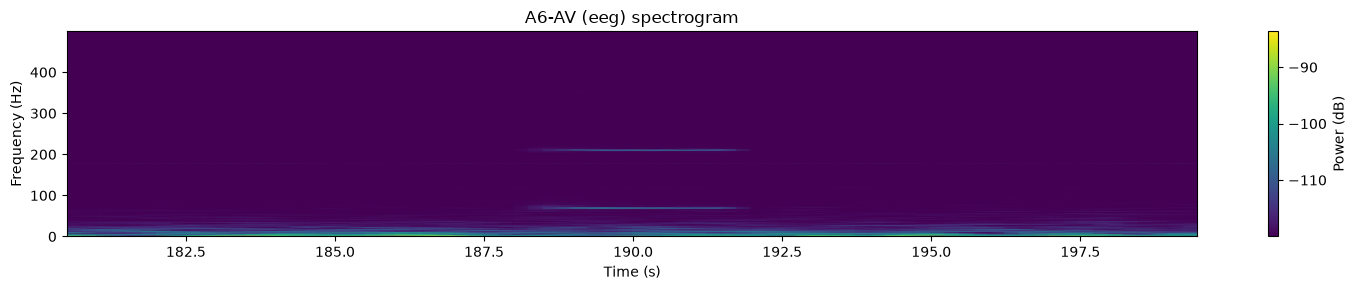

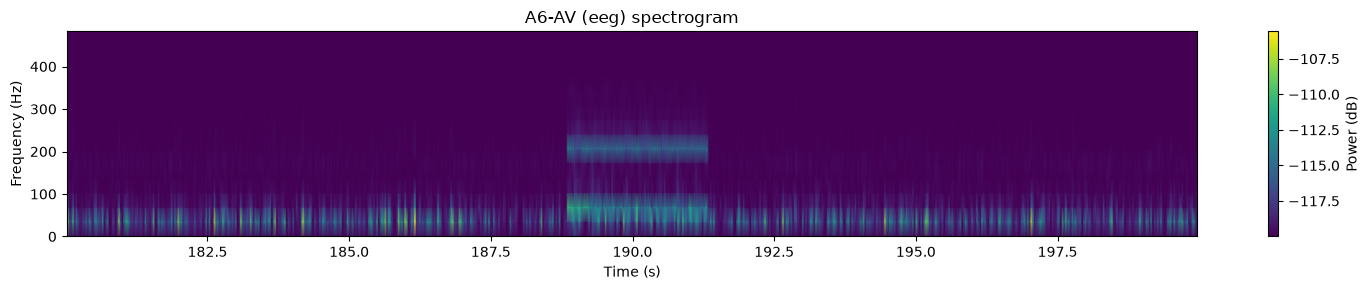

In [60]:
fig = plot_channel_spectrogram(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=1000,
    step_ms=500,
)
fig.show()
fig = plot_channel_spectrogram(
    signal,
    timestamps,
    ch_names,
    ch_types,
    channel_idx=5,
    start_time=180,
    end_time=200,
    window_ms=30,
    step_ms=30,
)
fig.show()

/var/folders/c1/5p016ykn6l74j06yf7xtfw500000gq/T/ipykernel_36986/3592610184.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


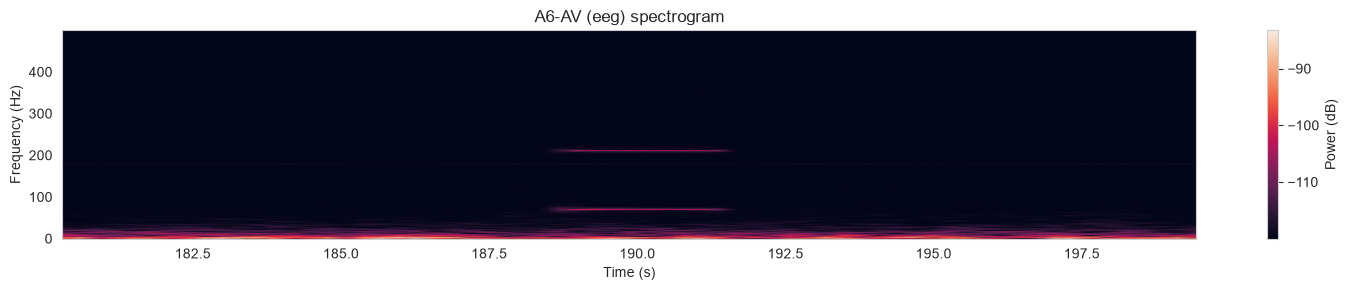

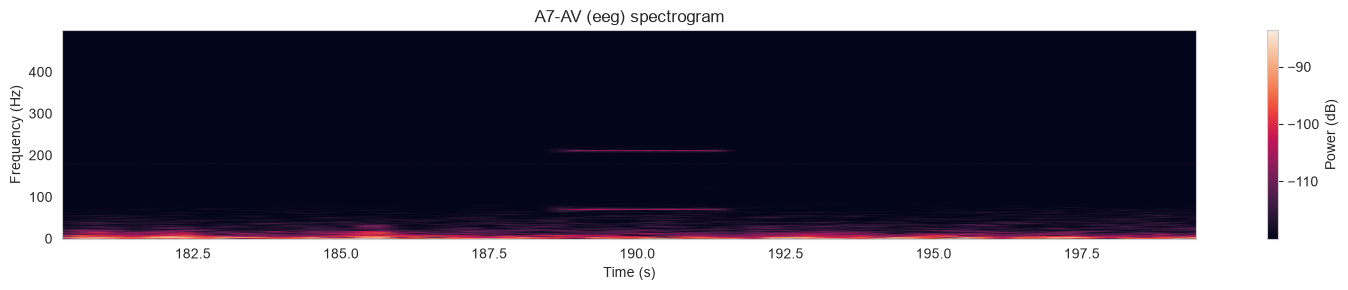

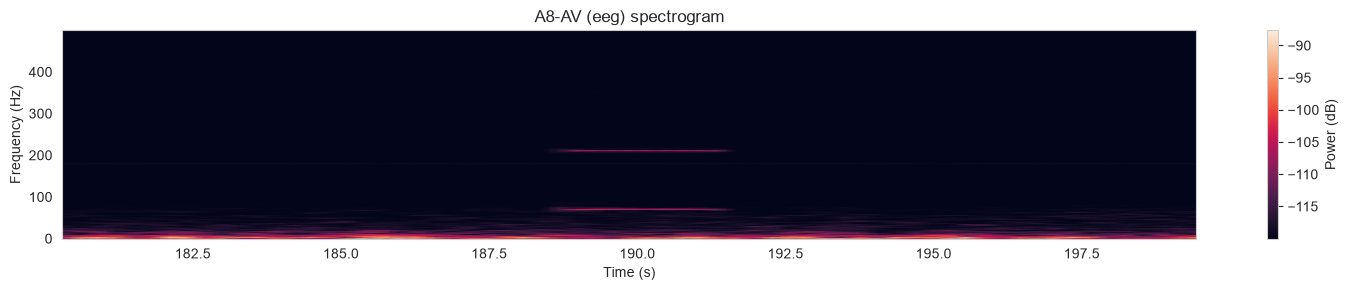

In [61]:
for ch_nbr in np.arange(5, 8):
    fig = plot_channel_spectrogram(
        signal,
        timestamps,
        ch_names,
        ch_types,
        channel_idx=ch_nbr,
        start_time=180,
        end_time=200,
    )
    fig.show()

In [38]:
ch_names[0]

np.str_('A1-AV')

In [47]:
on_channel = 5
(
    data.annotations.start[on_channel],
    data.annotations.end[on_channel],
    data.annotations.artifact[on_channel],
)

(np.float64(189.166), np.float64(189.214), np.int8(0))

plot power y and frequency x
fourier transform of the signal to get the frequency domain representation
check omni ieeg paper and zhang
check eymeric's code
wavelets
convolution

HFO shape accoridng to datasets, recording method
anat document in omni-ieeg dataset
250Hz can we detect them to not
segment by dataset and by sampling frequency - show
zhang 23 (implementation with code for it, take this as a baseline)
omni-ieeg paper:  reproduce pyHFO paper 0.8061 F1
zhang 25: